# 04_16. What distinguishes the four isoform-diversity quadrants?

In [ ]:
print("Hello World")

In [1]:
import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

import h5py
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.legend as _mlegend
import matplotlib.pyplot as plt
from scipy.sparse import issparse, csc_matrix
from scipy.stats import spearmanr, mannwhitneyu
import warnings, gc
warnings.filterwarnings("ignore")
gc.enable()

BASEDIR = "./../pacbio"
H5AD_DIR = f"{BASEDIR}/h5ads"
CSVS_DIR = "./../csvs"
RENYI_ALPHA = 2

# preferred plot formatting
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Arial"] + matplotlib.rcParams["font.sans-serif"]
TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
PANEL_TITLE_PAD = 3.0
plt.rcParams.update({
    "font.size": 6, "axes.titlesize": 6, "axes.labelsize": 6,
    "xtick.labelsize": 6, "ytick.labelsize": 6,
    "legend.fontsize": 6, "legend.title_fontsize": 6,
    "legend.labelspacing": 0.1, "legend.borderpad": 0.3, "legend.handletextpad": 0.2,
    "figure.titlesize": 6, "axes.labelweight": "bold", "axes.titleweight": "bold",
    "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN, "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD, "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD, "axes.titlepad": PANEL_TITLE_PAD,
    "savefig.dpi": 300, "savefig.bbox": "tight",
})
if not getattr(_mlegend.Legend, "_bold_title_patched", False):
    _orig_set_title = _mlegend.Legend.set_title
    def _bold_set_title(self, title, prop=None):
        res = _orig_set_title(self, title, prop=prop)
        self.get_title().set_fontweight("bold")
        return res
    _mlegend.Legend.set_title = _bold_set_title
    _mlegend.Legend._bold_title_patched = True

# reload figure_paths: a live kernel caches FIG_MAP
import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath  # routes figures/ -> figures/figureN/ via FIG_MAP

# Display order only: low mean first, then high mean, ascending variance within each. This
# list drives every reindex/xtick in the notebook. It is NOT what assigns genes to quadrants --
# see _QUAD_RULES in the `quadrants` cell, which keys each label to its own condition.
QUADRANT_ORDER = ["low mean / low var", "low mean / high var",
                  "high mean / low var", "high mean / high var"]
QCOL = dict(zip(QUADRANT_ORDER, ["#4c72b0", "#dd8452", "#55a868", "#c44e52"]))


def renyi_entropy(fracs, alpha=RENYI_ALPHA):
    """Identical to 04_05: H_alpha = log2(sum p^alpha) / (1 - alpha)."""
    fracs = fracs[fracs > 0]
    if len(fracs) == 0:
        return 0.0
    if np.isclose(alpha, 1.0):
        return float(-np.sum(fracs * np.log2(fracs)))
    if np.isinf(alpha):
        return float(-np.log2(np.max(fracs)))
    return float(np.log2(np.sum(np.power(fracs, alpha))) / (1.0 - alpha))

## 1. Rebuild the quadrants from the saved 04_05 table

Loads the per-(gene, cell type) Rényi table 04_05 wrote and reproduces its §8 median split, so
the quadrant definition here is identical to the one behind Fig 3E without re-running the
entropy computation.

In [2]:
ent = pd.read_csv(f"{CSVS_DIR}/per_gene_celltype_isoform_diversity_renyi_H_alpha{RENYI_ALPHA}.csv")
print(f"per (gene, cell type) entropy rows: {len(ent):,} | genes {ent.gene.nunique():,} | "
      f"cell types {ent.cell_ontology_class.nunique()}")

gene_var = (ent.groupby("gene")
              .agg(mean_entropy=("entropy", "mean"),
                   var_entropy=("entropy", "var"),
                   n_celltypes=("entropy", "size"),
                   n_isoforms=("n_isoforms", "first"))
              .dropna(subset=["var_entropy"]).reset_index())

mean_thr = gene_var["mean_entropy"].median()
var_thr = gene_var["var_entropy"].median()
hi_mean = gene_var["mean_entropy"] >= mean_thr
hi_var = gene_var["var_entropy"] >= var_thr
# Each label is bound to its OWN condition, so QUADRANT_ORDER can be reordered for display
# without touching the assignment.
_QUAD_RULES = [(hi_mean & ~hi_var, "high mean / low var"),
               (hi_mean & hi_var, "high mean / high var"),
               (~hi_mean & hi_var, "low mean / high var"),
               (~hi_mean & ~hi_var, "low mean / low var")]
assert sorted(l for _, l in _QUAD_RULES) == sorted(QUADRANT_ORDER), \
    "quadrant labels and QUADRANT_ORDER disagree"
gene_var["quadrant"] = np.select([cond for cond, _ in _QUAD_RULES],
                                 [lab for _, lab in _QUAD_RULES], default="unknown")

print(f"\nmedian split: mean_entropy {mean_thr:.3f} | var_entropy {var_thr:.4f}")
print(gene_var.groupby("quadrant").agg(
    genes=("gene", "size"), median_n_isoforms=("n_isoforms", "median"),
    median_n_celltypes=("n_celltypes", "median")).reindex(QUADRANT_ORDER).to_string())
print("\nNOTE median n_isoforms differs sharply across quadrants -- entropy is bounded by")
print("log2(n_isoforms), so the quadrants are partly isoform-count strata. Every comparison")
print("below is therefore ALSO reported stratified by isoform count.")

per (gene, cell type) entropy rows: 1,092,139 | genes 26,885 | cell types 128

median split: mean_entropy 1.103 | var_entropy 0.1548
                      genes  median_n_isoforms  median_n_celltypes
quadrant                                                          
low mean / low var     8703                4.0                23.0
low mean / high var    4338                7.0                16.0
high mean / low var    4336               11.0                13.0
high mean / high var   8706               21.0                47.0

NOTE median n_isoforms differs sharply across quadrants -- entropy is bounded by
log2(n_isoforms), so the quadrants are partly isoform-count strata. Every comparison
below is therefore ALSO reported stratified by isoform count.


## 2. Attach per-isoform annotation

Reads the transcript to gene map straight from the h5ad `var` with h5py (cheap, no matrix), then
joins the SQANTI3 transcript-level classification. SQANTI3 rather than pigeon because pigeon
leaves `coding` / `predicted_NMD` empty. Only the needed columns are parsed -- the file is ~2.9 GB.

In [3]:
H5 = f"{H5AD_DIR}/all_samples_pacbio_recollapsed_raw_counts_ensemblids_bc_anndata_preprocessed_with_isofrac.h5ad"


def _dec(v):
    return np.array([x.decode() if isinstance(x, bytes) else x for x in v])


def _var_col(f, name):
    o = f["var"][name]
    if isinstance(o, h5py.Group):
        return pd.Categorical.from_codes(o["codes"][:], categories=_dec(o["categories"][:])).astype(str)
    v = o[:]
    return _dec(v) if v.dtype.kind in ("S", "O") else v


with h5py.File(H5, "r") as f:
    iso2gene = pd.DataFrame({"isoform": _var_col(f, "_index"),
                             "gene_name": _var_col(f, "gene_name")})
print(f"isoforms in the analysed object: {len(iso2gene):,}")

USE = ["isoform", "structural_category", "subcategory", "coding", "CDS_length", "predicted_NMD"]
cls = pd.read_csv(f"{CSVS_DIR}/all_samples_recollapsed_sqanti3_classification_ensemblids.csv",
                  usecols=USE, low_memory=False)
iso = iso2gene.merge(cls, on="isoform", how="left")
iso = iso[iso["gene_name"].isin(set(gene_var["gene"]))].copy()
iso = iso.merge(gene_var[["gene", "quadrant", "n_isoforms"]], left_on="gene_name",
                right_on="gene", how="left").drop(columns="gene")

NOVEL = {"novel_in_catalog", "novel_not_in_catalog"}
iso["is_novel"] = iso["structural_category"].isin(NOVEL)
print(f"isoforms joined to a quadrant: {len(iso):,} "
      f"({iso['structural_category'].isna().mean()*100:.1f}% with no SQANTI record)")
print(iso.groupby("quadrant").size().reindex(QUADRANT_ORDER).to_string())

isoforms in the analysed object: 478,192
isoforms joined to a quadrant: 476,081 (4.0% with no SQANTI record)
quadrant
low mean / low var       96658
low mean / high var      51677
high mean / low var      84421
high mean / high var    243325


## 3. Novel versus known composition per quadrant  *(analysis 4)*

Fraction of each gene's isoforms that are novel (NIC + NNC). Two readings: it links the
diversity axis to the novelty story, and it checks whether high entropy is partly an artefact of
novel-isoform calls rather than regulated usage -- if the high-diversity quadrants are
disproportionately novel, some entropy may be collapse-boundary noise.

                       count    25%    50%    75%
quadrant                                         
low mean / low var    8700.0  0.250  0.600  0.800
low mean / high var   4337.0  0.333  0.611  0.786
high mean / low var   4336.0  0.406  0.667  0.816
high mean / high var  8706.0  0.462  0.660  0.792


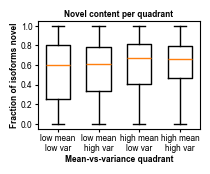

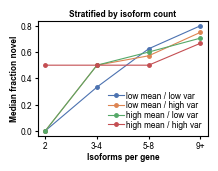

In [4]:
pg = (iso.dropna(subset=["structural_category"])
        .groupby(["gene_name", "quadrant"])
        .agg(frac_novel=("is_novel", "mean"), n_iso=("is_novel", "size")).reset_index())

print(pg.groupby("quadrant")["frac_novel"].describe()[["count", "25%", "50%", "75%"]]
        .reindex(QUADRANT_ORDER).round(3).to_string())

# One figure per panel, each free-standing for the manuscript.
fig, ax = plt.subplots(figsize=(2.1, 1.4))
ax.boxplot([pg.loc[pg.quadrant == q, "frac_novel"].dropna() for q in QUADRANT_ORDER],
           labels=[q.replace(" / ", "\n") for q in QUADRANT_ORDER], showfliers=False, widths=0.6)
ax.set_xlabel("Mean-vs-variance quadrant")
ax.set_ylabel("Fraction of isoforms novel")
ax.set_title("Novel content per quadrant", pad=PANEL_TITLE_PAD)
fig.savefig(figpath("04_16_quadrant_novel_fraction.pdf"), bbox_inches="tight")
plt.show()

# Stratified by isoform count: the quadrants differ in n_isoforms, so the comparison above
# could simply be reporting that. This checks the difference survives within a count stratum.
pg["iso_bin"] = pd.cut(pg["n_iso"], [0, 2, 4, 8, 10**6], labels=["2", "3-4", "5-8", "9+"])
fig, ax = plt.subplots(figsize=(2.2, 1.5))
for q in QUADRANT_ORDER:
    sub = pg[pg.quadrant == q].groupby("iso_bin", observed=True)["frac_novel"].median()
    ax.plot(range(len(sub)), sub.values, marker="o", ms=2.5, lw=0.8, color=QCOL[q], label=q)
ax.set_xticks(range(4))
ax.set_xticklabels(["2", "3-4", "5-8", "9+"])
ax.set_xlabel("Isoforms per gene")
ax.set_ylabel("Median fraction novel")
ax.set_title("Stratified by isoform count", pad=PANEL_TITLE_PAD)
ax.legend(frameon=False)
fig.savefig(figpath("04_16_quadrant_novel_fraction_by_isoform_count.pdf"), bbox_inches="tight")
plt.show()

## 4. What kind of diversity  *(analysis 2)*

The SQANTI subcategory mix of each quadrant's isoforms. This is the analysis that converts "how
much diversity" into "what kind": whether high-entropy genes diversify at transcript boundaries
(alternative 5'/3' ends) or by internal splicing (novel junctions, intron retention). It is the
diversity-axis counterpart of the transcript-boundary results in 03_04.

In [15]:
sc_tab

,quadrant,subcategory,n,frac
0,high mean / high var,3prime_fragment,17080,0.073176
1,high mean / high var,5prime_fragment,16248,0.069611
2,high mean / high var,alternative_3end,8561,0.036678
3,high mean / high var,alternative_3end5end,7511,0.032179
4,high mean / high var,alternative_5end,5257,0.022523
5,high mean / high var,at_least_one_novel_splicesite,77676,0.332786
6,high mean / high var,combination_of_known_junctions,31327,0.134214
7,high mean / high var,combination_of_known_splicesites,28461,0.121935
8,high mean / high var,internal_fragment,8022,0.034369
9,high mean / high var,intron_retention,17972,0.076997


subcategory           at_least_one_novel_splicesite  combination_of_known_splicesites  combination_of_known_junctions  intron_retention  3prime_fragment  5prime_fragment  alternative_3end  alternative_3end5end  other
quadrant                                                                                                                                                                                                                
low mean / low var                            0.507                             0.109                           0.044             0.069            0.042            0.032             0.037                 0.027  0.133
low mean / high var                           0.454                             0.099                           0.058             0.067            0.060            0.048             0.038                 0.032  0.144
high mean / low var                           0.396                             0.120                           0.096             0.

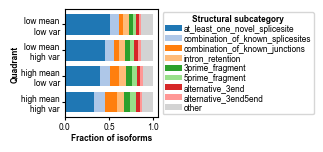

In [21]:
sc_tab = (iso.dropna(subset=["subcategory"])
            .groupby(["quadrant", "subcategory"]).size().rename("n").reset_index())
sc_tab["frac"] = sc_tab.groupby("quadrant")["n"].transform(lambda s: s / s.sum())
piv = (sc_tab.pivot(index="quadrant", columns="subcategory", values="frac")
             .reindex(QUADRANT_ORDER).fillna(0))
keep = piv.mean(axis=0).sort_values(ascending=False).head(8).index
piv_top = piv[keep].copy()
piv_top["other"] = 1 - piv_top.sum(axis=1)
print(piv_top.round(3).to_string())

# Colour to MATCH Figure 2C. 03_02 draws subcategories with pandas' default prop_cycle over
# classification["subcategory"].value_counts().index, so a subcategory's colour is fixed by its
# RANK IN GLOBAL FREQUENCY, not by its position in any one plot. Reproduce that rule and key the
# result by NAME, so a subcategory keeps its colour here even though this panel shows only the
# top 8. (tab20-by-position, used before, gave this panel its own arbitrary assignment.)
_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
_cycle = plt.get_cmap("tab20").colors
SUBCAT_COLORS = {sc: _cycle[i % len(_cycle)]
                 for i, sc in enumerate(iso["subcategory"].value_counts().index)}
SUBCAT_COLORS["other"] = "lightgrey"        # aggregated remainder, not a real subcategory

fig, ax = plt.subplots(figsize=(1.2, 1.4))
left = np.zeros(len(piv_top))
for j, c in enumerate(piv_top.columns):
    ax.barh(range(len(piv_top)), piv_top[c].values, left=left, height=0.8,
            color=SUBCAT_COLORS.get(str(c), "lightgrey"), label=str(c))
    left += piv_top[c].values
ax.set_yticks(range(len(piv_top)))
ax.set_yticklabels([q.replace(" / ", "\n") for q in piv_top.index], fontsize=6)
ax.invert_yaxis()
ax.set_xlabel("Fraction of isoforms")
ax.set_ylabel("Quadrant")
# ax.set_title("Structural subcategory mix per quadrant", pad=PANEL_TITLE_PAD)
ax.legend(fontsize=6, frameon=True, title = "Structural subcategory", bbox_to_anchor=(1.01, 0.5), loc="center left")
fig.savefig(figpath("04_16_quadrant_subcategory_mix.pdf"), bbox_inches="tight")
plt.show()

## 5. Productive or degradative diversity  *(analysis 3)*

Per quadrant: fraction of isoforms predicted coding, predicted-NMD rate, and the spread of CDS
length *within* each gene. The question is whether multi-isoform genes maintain several
functional proteins or accumulate NMD targets and fragments -- a distinction the entropy value
alone cannot make.

`CDS_length` is used throughout, never `ORF_length`, which is the CDS genomic span and is
corrupt. `predicted_NMD` comes from the same CDS machinery, so its rates are comparable between
quadrants but should not be quoted as absolute.

                       n_iso  frac_coding  frac_nmd_of_coding  median_within_gene_CDS_cv
quadrant                                                                                
low mean / low var     93162        0.612               0.126                      0.305
low mean / high var    49690        0.571               0.114                      0.332
high mean / low var    80603        0.620               0.116                      0.424
high mean / high var  233411        0.622               0.119                      0.435


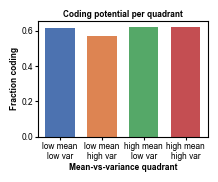

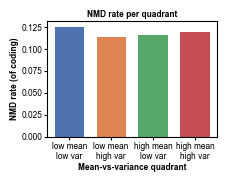

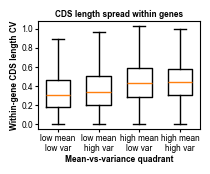

In [72]:
cod = iso.dropna(subset=["coding"]).copy()
cod["is_coding"] = cod["coding"].astype(str).str.lower().eq("coding")
cod["is_nmd"] = cod["predicted_NMD"].astype(str).str.lower().isin(["true", "yes", "1"])

summ = (cod.groupby("quadrant")
          .agg(n_iso=("is_coding", "size"), frac_coding=("is_coding", "mean"))
          .reindex(QUADRANT_ORDER))
summ["frac_nmd_of_coding"] = (cod[cod.is_coding].groupby("quadrant")["is_nmd"].mean()
                                .reindex(QUADRANT_ORDER))
# within-gene CDS spread: how different are the coding isoforms of the same gene?
cds = (cod[cod.is_coding].dropna(subset=["CDS_length"])
         .groupby(["gene_name", "quadrant"])["CDS_length"]
         .agg(["size", "std", "mean"]).reset_index())
cds = cds[cds["size"] >= 2]
cds["cv"] = cds["std"] / cds["mean"]
summ["median_within_gene_CDS_cv"] = cds.groupby("quadrant")["cv"].median().reindex(QUADRANT_ORDER)
print(summ.round(3).to_string())

# One figure per panel.
for _col, _lab, _title, _fname in (
        ("frac_coding", "Fraction coding", "Coding potential per quadrant",
         "04_16_quadrant_coding_fraction.pdf"),
        ("frac_nmd_of_coding", "NMD rate (of coding)", "NMD rate per quadrant",
         "04_16_quadrant_nmd_rate.pdf")):
    fig, ax = plt.subplots(figsize=(2.2, 1.5))
    ax.bar(range(4), summ[_col].values, color=[QCOL[q] for q in QUADRANT_ORDER], width=0.7)
    ax.set_xticks(range(4))
    ax.set_xticklabels([q.replace(" / ", "\n") for q in QUADRANT_ORDER])
    ax.set_xlabel("Mean-vs-variance quadrant")
    ax.set_ylabel(_lab)
    ax.set_title(_title, pad=PANEL_TITLE_PAD)
    fig.savefig(figpath(_fname), bbox_inches="tight")
    plt.show()

# within-gene CDS spread: how different are the coding isoforms of the same gene?
fig, ax = plt.subplots(figsize=(2.1, 1.4))
ax.boxplot([cds.loc[cds.quadrant == q, "cv"].dropna() for q in QUADRANT_ORDER],
           labels=[q.replace(" / ", "\n") for q in QUADRANT_ORDER], showfliers=False, widths=0.6)
ax.set_xlabel("Mean-vs-variance quadrant")
ax.set_ylabel("Within-gene CDS length CV")
ax.set_title("CDS length spread within genes", pad=PANEL_TITLE_PAD)
fig.savefig(figpath("04_16_quadrant_cds_cv.pdf"), bbox_inches="tight")
plt.show()

## 6. Which cell types drive the high-variance genes  *(analysis 5)*

For each gene in the two high-variance quadrants, find the cell type whose entropy deviates most
from that gene's mean, and tabulate how often each cell type is the driver. If a handful of cell
types account for most of the variance -- male germ cells are the obvious candidate, since they
top the cell-type entropy ranking in 04_05 -- then these quadrants are a statement about those
populations rather than about cell-type identity in general.

genes considered: 13,044
top driver cell types (share of all high-variance genes):
cell_ontology_class
spermatid                                   0.125
spermatocyte                                0.088
fibroblast                                  0.025
bladder urothelial cell                     0.019
macrophage                                  0.018
kidney epithelial cell                      0.017
pancreatic stellate cell                    0.017
enterocyte of epithelium proper of ileum    0.015
stromal cell of ovary                       0.015
plasma cell                                 0.014
type ii pneumocyte                          0.014
b cell                                      0.013
acinar cell of salivary gland               0.012
basal cell                                  0.011
endothelial cell                            0.011

by direction:
direction                                 higher  lower
cell_ontology_class                                    
spermatid           

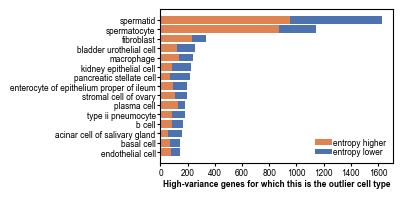

In [39]:
hv = gene_var.loc[gene_var["quadrant"].isin(["high mean / high var", "low mean / high var"]),
                  ["gene", "quadrant"]]
e = ent.merge(hv, on="gene", how="inner")
e["dev"] = e["entropy"] - e.groupby("gene")["entropy"].transform("mean")
e["absdev"] = e["dev"].abs()
drv = e.loc[e.groupby("gene")["absdev"].idxmax(), ["gene", "quadrant", "cell_ontology_class", "dev"]]
drv["direction"] = np.where(drv["dev"] > 0, "higher", "lower")

top = drv["cell_ontology_class"].value_counts().head(15)
print(f"genes considered: {len(drv):,}")
print(f"top driver cell types (share of all high-variance genes):")
print((top / len(drv)).round(3).to_string())
print("\nby direction:")
print(pd.crosstab(drv["cell_ontology_class"], drv["direction"]).loc[top.index].to_string())

fig, ax = plt.subplots(figsize=(3.0, 2.0))
order = top.index[::-1]
hi = [((drv.cell_ontology_class == c) & (drv.direction == "higher")).sum() for c in order]
lo = [((drv.cell_ontology_class == c) & (drv.direction == "lower")).sum() for c in order]
ax.barh(range(len(order)), hi, color="#dd8452", label="entropy higher")
ax.barh(range(len(order)), lo, left=hi, color="#4c72b0", label="entropy lower")
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=6)
ax.set_xlabel("High-variance genes for which this is the outlier cell type")
ax.legend(fontsize=6, frameon=False)
fig.savefig(figpath("04_16_quadrant_driver_celltypes.pdf"))
plt.show()

## 7. Donor reproducibility of the variance  *(analysis 1 -- HEAVY, run on bigmem)*

**The validity check, and the one that governs how much the sections above are worth.** Per-gene
`Var(H)` is computed from cell-type means that are themselves estimated from limited cells, so
some of the variance is sampling noise. This splits donors into two halves, recomputes the
entire per-(gene, cell type) entropy table independently within each half, and correlates the
resulting `Var(H)`.

A high correlation means the high-variance quadrants are reproducible biology. A low one means
they are substantially noise, and the quadrant split behind Fig 3E is not stable.

This is the only section that loads the count matrix (203,311 x 478,192), so run the notebook on
bigmem from here. Donors are split by alternating rank of cell count, so both halves carry a
comparable number of cells.

loaded 203,311 cells x 478,192 isoforms
donor split: {'A': ['TSP19', 'TSP2', 'TSP21', 'TSP28', 'TSP33', 'TSP9'], 'B': ['TSP10', 'TSP25', 'TSP27', 'TSP32', 'TSP4', 'TSP7']}
cells per half: {'A': 114852, 'B': 88459}
half A: 654,300 (gene, cell type) entries, 24,996 genes
half B: 503,789 (gene, cell type) entries, 25,173 genes

genes with Var(H) in both halves: 15,360
Spearman(Var_A, Var_B) = 0.731  (p=0.0e+00)
   within low mean / low var     n= 4,642  rho=0.661
   within low mean / high var    n= 2,073  rho=0.391
   within high mean / low var    n= 2,088  rho=0.336
   within high mean / high var   n= 6,557  rho=0.514

rho near 0 would mean the high-variance quadrants are largely sampling noise;
a high rho means the variance is a reproducible property of the gene.


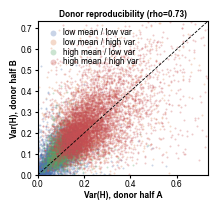

6260

In [53]:
import scanpy as sc

adata = sc.read_h5ad(H5)
gene_col = "gene_name"
print(f"loaded {adata.shape[0]:,} cells x {adata.shape[1]:,} isoforms")

frac = adata.layers["isoform_fraction"]
frac = frac.tocsc() if issparse(frac) else frac
genes_v = adata.var[gene_col].values
uniq_g, g_idx = np.unique(genes_v, return_inverse=True)
gcols = [np.where(g_idx == g)[0] for g in range(len(uniq_g))]
iso2g = csc_matrix((np.ones(len(genes_v), dtype=np.float32),
                    (np.arange(len(genes_v)), g_idx)), shape=(len(genes_v), len(uniq_g)))

pop = adata.obs["cell_ontology_class"].astype(str).values
don = adata.obs["donor"].astype(str).values
MIN_CELLS = 10

# alternate donors by cell count so the halves are comparably sized
_order = pd.Series(don).value_counts().index.tolist()
half = {d: ("A" if i % 2 == 0 else "B") for i, d in enumerate(_order)}
mask_half = np.array([half[d] for d in don])
print("donor split:", {h: sorted(d for d in half if half[d] == h) for h in ("A", "B")})
print("cells per half:", {h: int((mask_half == h).sum()) for h in ("A", "B")})


def entropy_table(cell_mask):
    """Re-derive the 04_05 per-(gene, cell type) Renyi table within a subset of cells."""
    recs = []
    for ct in sorted(set(pop[cell_mask])):
        m = cell_mask & (pop == ct)
        if m.sum() < MIN_CELLS:
            continue
        sub = frac[m, :]
        colsum = np.asarray(sub.sum(axis=0)).ravel()
        nexpr = np.asarray(((sub > 0).astype(np.float32) @ iso2g > 0).sum(axis=0)).ravel()
        for g in np.where(nexpr >= MIN_CELLS)[0]:
            cols = gcols[g]
            if len(cols) < 2:
                continue
            f_ = colsum[cols] / nexpr[g]
            if f_.sum() <= 0:
                continue
            recs.append((uniq_g[g], ct, renyi_entropy(f_ / f_.sum())))
    return pd.DataFrame(recs, columns=["gene", "cell_ontology_class", "entropy"])


halves = {}
for h in ("A", "B"):
    halves[h] = entropy_table(mask_half == h)
    print(f"half {h}: {len(halves[h]):,} (gene, cell type) entries, "
          f"{halves[h].gene.nunique():,} genes")

vA = halves["A"].groupby("gene")["entropy"].agg(["var", "size"]).rename(
    columns={"var": "var_A", "size": "n_A"})
vB = halves["B"].groupby("gene")["entropy"].agg(["var", "size"]).rename(
    columns={"var": "var_B", "size": "n_B"})
rep = (vA.join(vB, how="inner").dropna()
         .query("n_A >= 5 and n_B >= 5")
         .join(gene_var.set_index("gene")["quadrant"], how="left"))
rep.to_csv(f"{CSVS_DIR}/04_16_var_entropy_donor_reproducibility.csv")

rho, pval = spearmanr(rep["var_A"], rep["var_B"])
print(f"\ngenes with Var(H) in both halves: {len(rep):,}")
print(f"Spearman(Var_A, Var_B) = {rho:.3f}  (p={pval:.1e})")
for q in QUADRANT_ORDER:
    s = rep[rep["quadrant"] == q]
    if len(s) > 10:
        r_, _ = spearmanr(s["var_A"], s["var_B"])
        print(f"   within {q:22s} n={len(s):>6,}  rho={r_:.3f}")
print("\nrho near 0 would mean the high-variance quadrants are largely sampling noise;")
print("a high rho means the variance is a reproducible property of the gene.")

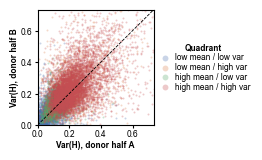

In [73]:
fig, ax = plt.subplots(figsize=(1.5, 1.5))
for q in QUADRANT_ORDER:
    s = rep[rep["quadrant"] == q]
    ax.scatter(s["var_A"], s["var_B"], s=2, alpha=0.3, linewidths=0, color=QCOL[q], label=q)
lim = float(np.nanpercentile(pd.concat([rep["var_A"], rep["var_B"]]), 99))
ax.plot([0, lim], [0, lim], "k--", lw=0.6)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("Var(H), donor half A")
ax.set_ylabel("Var(H), donor half B")
# ax.set_title(f"Donor reproducibility (rho={rho:.2f})", pad=PANEL_TITLE_PAD)
ax.legend(fontsize=6, frameon=False, markerscale=3, title = "Quadrant",
         loc = 6, bbox_to_anchor = (1.0,0.5), borderaxespad=0)
fig.savefig(figpath("04_16_var_entropy_donor_reproducibility.pdf"))
plt.show()